In [1]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
with open('/content/drive/MyDrive/Loan_Default.csv', 'r') as f:
    for i in range(5):
        print(f.readline())


Loan_Default

ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1

24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,,,,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.72881356,south,direct,1,45.0

24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,,,,360.0,not_neg,not_int,lpsm,,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,,North,direct,1,

24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.01968504,south,direct,0,46.0



In [4]:
df= pd.read_csv('/content/drive/MyDrive/Loan_Default.csv',low_memory=False, skiprows=1)


In [5]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [6]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [7]:
df.shape


(148670, 34)

In [8]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


NUMERICAL FEATURES

In [9]:
df['Status'].value_counts(normalize=True)

,proportion
Status,
0,0.753555
1,0.246445


Status represents the risk event (Defaulting), the binary flags are mapped like this:
Status = 1 (24.6%): These are the people who Defaulted on their loans (failed to pay the bank back).
Status = 0 (75.3%): These are the people who Successfully Paid or are actively paying back their loans without issues.

In [10]:
df['Credit_Worthiness'].value_counts()

,count
Credit_Worthiness,
l1,142344
l2,6326


L1: Safe borrowers, no defaults and good credit score, L2: more prone to defaults

In [11]:
df['open_credit'].value_counts()

,count
open_credit,
nopc,148114
opc,556


nopc: no open bank accounts or passbooks, usually safe do not live in debts, opc: might be dangerous, might live in debts.

In [12]:
(df['Interest_rate_spread']>0).sum()/len(df['Interest_rate_spread'])


np.float64(0.6063025492701958)

Interest_rate_Spread= Lending_Rate-Deposit_Rate, how is deposit rate higher for some banks than the lending rate itself? three possible reasons are:
1. Subsidized & Government-Backed Loans (Most Likely)
In housing and development sectors, governments frequently step in to make borrowing affordable for low-income families, first-time homebuyers, or agricultural workers.
The Mechanism: To keep commercial banks happy, the government tells the bank: "Hand out these home loans at a highly subsidized, below-market rate (e.g., 3%). We know your deposit costs are 4%. We, the government, will compensate you for the negative difference behind the scenes."
In the Dataset: The raw column values capture the immediate contractual rate given to the borrower versus the bank’s standard cost of funds, resulting in a negative calculation in your raw dataset.

 2. The Era of Global Negative Interest Rate Policies (NIRP)
Your dataset tracks historical loans around 2019. This was the absolute peak era of Negative Interest Rate Policies implemented by central banks across Europe, Switzerland, and Japan to combat economic deflation.  
Kaggle
The Chaos: Central banks literally charged commercial banks a fee to store cash. To avoid paying this penalty, commercial banks desperately needed to get money out the door.  
IG
The Result: Banks cut lending rates drastically—sometimes dropping them so low that the nominal interest rate spread technically flipped negative relative to their rigid, near-zero deposit obligations to retail savers.

3. Teaser Rates and "Introductory" Multi-Year Spreads
Many modern mortgage products use structured, variable pricing models to attract buyers:
The Hook: A bank might offer a "Teaser Rate" for the first 12 to 24 months of a 360-month loan. During this introductory period, the lending rate is kept artificially low to win the client over from a competitor.
The Catch: The bank accepts a negative spread for the first year or two, knowing they will make a massive profit once the rate automatically jacks up for the remaining 28 years of the term

In [13]:
(df['Interest_rate_spread']==0).sum()/ len(df['Interest_rate_spread'])

np.float64(6.053675926548732e-05)

In [14]:
df['Neg_ammortization'].value_counts()

,count
Neg_ammortization,
not_neg,133420
neg_amm,15129


A huge red flag, neg ammortization refers to pending loan interests due to untimely payement, neg_amm buyers should be flagged.

In [15]:
print(df.groupby('Neg_ammortization')['Status'].agg(['count','mean']))

                    count      mean
Neg_ammortization                  
neg_amm             15129  0.445965
not_neg            133420  0.223805


Makes Sense, negative amm flagged people will be more probable to defaulting than non neg_amm.

In [16]:
df['Credit_Score'].mean()

np.float64(699.7891033833322)

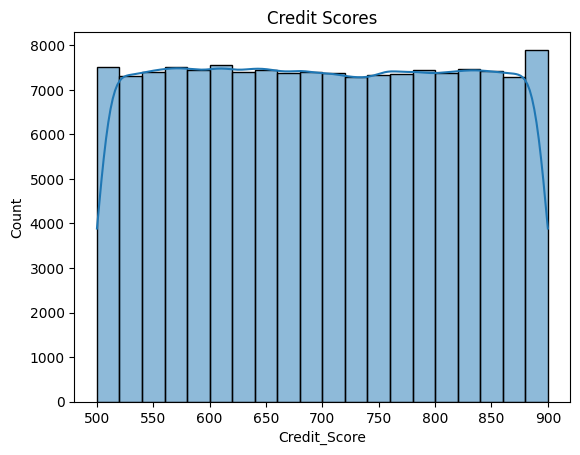

In [17]:
sns.histplot(df['Credit_Score'], bins=20,kde=True)
plt.title('Credit Scores')
plt.show()

In [18]:
df['Credit_Score'].skew()

np.float64(0.004766756957725898)

In [19]:
df['Interest_rate_spread'].skew()


np.float64(0.28076233013056445)

Bank loves hiking interest rate for a fair few, otherwise skeweness is manageable

/tmp/ipykernel_53091/3220485500.py:4: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Credit_Score', 'Interest Spread')


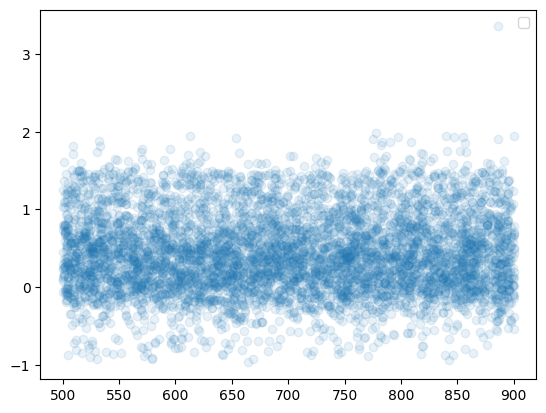

In [20]:
sample=df.sample(frac=0.05)
plt.scatter(sample['Credit_Score'], sample['Interest_rate_spread'], alpha=0.1)

plt.legend('Credit_Score', 'Interest Spread')
plt.show()

In [21]:
df['Interest_rate_spread'].min()

-3.638

In [22]:
df['Credit_Score'].max()

900

In [23]:
bins = [500, 600, 700, 800, 900]
labels = ['500-600', '600-700', '700-800', '800-900']

df['Credit_Category'] = pd.cut(df['Credit_Score'], bins=bins, labels=labels)
analysis = df.groupby('Credit_Category')['Status'].agg(['count', 'mean']).reset_index()
analysis.columns = ['Category', 'Number_of_Borrowers', 'Default_Rate']

print(analysis)

  Category  Number_of_Borrowers  Default_Rate
0  500-600                37189      0.245825
1  600-700                37247      0.245013
2  700-800                36753      0.242592
3  800-900                37124      0.251966


/tmp/ipykernel_53091/2123437335.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = df.groupby('Credit_Category')['Status'].agg(['count', 'mean']).reset_index()


In [24]:
# Checking if high-score people have bigger loans
print(df.groupby('Credit_Category')['loan_amount'].mean())

Credit_Category
500-600    330276.116594
600-700    330667.583966
700-800    331909.898512
800-900    331773.138670
Name: loan_amount, dtype: float64


/tmp/ipykernel_53091/60848501.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Credit_Category')['loan_amount'].mean())


Very Interesting, loan amount and credit score are pretty flat in nature no difference is seen much in 500 vs 900 credit score users, probably because 900s are given too much freedom and 500s too less, these 2 might not be good features alone.

In [25]:
# Group by credit score, but ONLY for rows where the interest rate spread is normal (> 0)
print(df[df['Interest_rate_spread'] > 0].groupby('Credit_Category')['Interest_rate_spread'].mean())

Credit_Category
500-600    0.606758
600-700    0.601868
700-800    0.606387
800-900    0.604123
Name: Interest_rate_spread, dtype: float64


/tmp/ipykernel_53091/854355370.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df[df['Interest_rate_spread'] > 0].groupby('Credit_Category')['Interest_rate_spread'].mean())


In [26]:
# Check how many UNIQUE values are in that column
unique_counts = df['Interest_rate_spread'].nunique()
print(f"Unique values in Spread: {unique_counts}")

# Check for missing values that might be causing the NaN
missing_values = df['Interest_rate_spread'].isnull().sum()
print(f"Missing values in Spread: {missing_values}")

Unique values in Spread: 22516
Missing values in Spread: 36639


In [27]:

print(df[df['Interest_rate_spread'].isnull()]['Status'].mean())
print(df[df['Interest_rate_spread'].notnull()]['Status'].mean())

1.0
0.0


AHA! SO interest_rate_spread was leaking the model, the defaulters were crashing the interest_rate_spread and not written on, the defaulters were not logged in the upfront charges and hence no irs was updated, this is clearly a leaking variable. we need to drop it.

In [28]:
print(df[df['Upfront_charges'].isnull()]['Status'].mean())
print(df[df['Upfront_charges'].notnull()]['Status'].mean())

0.9203874678371424
0.0014033092416626922


In [29]:
print(df[df['rate_of_interest'].isnull()]['Status'].mean())
print(df[df['rate_of_interest'].notnull()]['Status'].mean())

1.0
0.0017820388306261194


In [30]:

df.drop(columns=['Interest_rate_spread', 'Upfront_charges','rate_of_interest'], inplace=True, errors='ignore')

print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'Credit_Category'],
      dtype='object')


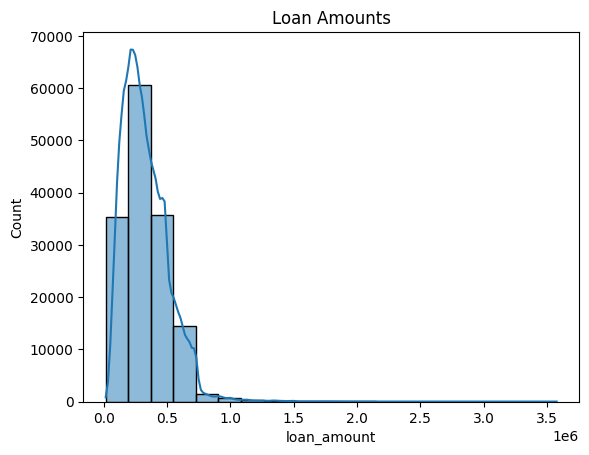

In [31]:
sns.histplot(df['loan_amount'], bins=20,kde=True)
plt.title('Loan Amounts')
plt.show()

loan_bin
(16499.999, 126500.0]    0.330825
(126500.0, 176500.0]     0.280567
(176500.0, 216500.0]     0.259120
(216500.0, 256500.0]     0.242899
(256500.0, 296500.0]     0.238679
(296500.0, 346500.0]     0.226623
(346500.0, 406500.0]     0.219469
(406500.0, 476500.0]     0.207478
(476500.0, 566500.0]     0.207270
(566500.0, 3576500.0]    0.240372
Name: Status, dtype: float64


/tmp/ipykernel_53091/4103892974.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df.groupby('loan_bin')['Status'].mean()


<Axes: xlabel='loan_bin'>

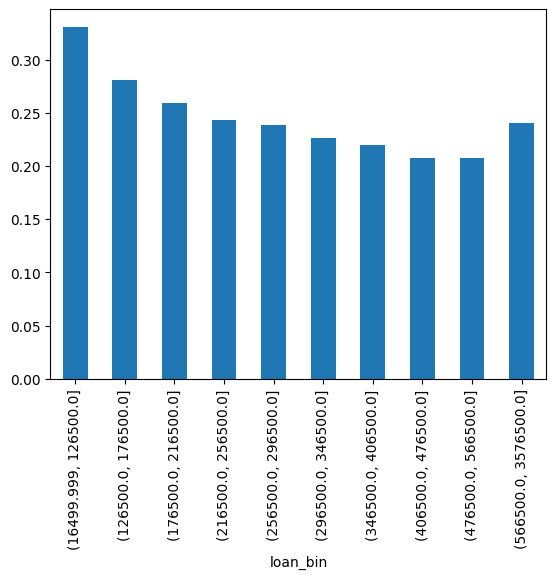

In [32]:
df['loan_bin'] = pd.qcut(df['loan_amount'], q=10)  # 10 bins

default_rate = df.groupby('loan_bin')['Status'].mean()

print(default_rate)
default_rate.plot(kind='bar')

A very expected plot it plots loan amounts vs default rates, it is not much of a difference, but the lesser loans might be provided to poorer people, so they might default more, in middle loans are generally repayed and a sthey get higher default rate increases again, a good feature.

In [33]:
df.groupby('interest_only')['Status'].mean()

,Status
interest_only,
int_only,0.273136
not_int,0.245105


An interest_only loan is a specialized type of loan where, for a specific initial period (usually the first 5 to 10 years of a 30-year mortgage), the borrower is only required to pay the interest charges, and zero dollars go toward paying down the actual debt.

Another flat feature then, both int_only and not_int have less defaulters expected was that int_only is a risky loan, will have more defaulters.

LTV: Loan to Value ratio, measures how big loan is to the property or asset its being taken for.

In [34]:
df['LTV'].describe()

,LTV
count,133572.000000
mean,72.746457
std,39.967603
min,0.967478
25%,60.474860
50%,75.135870
75%,86.184211
max,7831.250000


In [35]:

print("Default rate when LTV is MISSING:")
print(df[df['LTV'].isnull()]['Status'].mean())

print("\nDefault rate when LTV is PRESENT:")
print(df[df['LTV'].notnull()]['Status'].mean())

Default rate when LTV is MISSING:
0.99986753212346

Default rate when LTV is PRESENT:
0.16128380199442996


Wow, so ltv is indeed having a big status hike when NANS are resent, it may be not be leakage entirely, but we nned to seperate the NANs.

In [36]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'Credit_Category', 'loan_bin'],
      dtype='object')

In [37]:

df.drop(columns=['ltv_missing'], inplace=True, errors='ignore')

print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'Credit_Category', 'loan_bin'],
      dtype='object')


In [38]:



bins = [0, 60, 70, 80, 90, 100, 150]  # 7 edge values
labels = ["0-60", "60-70", "70-80", "80-90", "90-100", "100-150"]  # 6 string labels


df.loc[df['LTV'].notnull(), 'LTV_bin'] = pd.cut(
    df.loc[df['LTV'].notnull(), 'LTV'],
    bins=bins,
    labels=labels
)


clean_analysis = df.groupby('LTV_bin', observed=False)['Status'].mean()
print(clean_analysis)

LTV_bin
0-60       0.139229
60-70      0.124975
70-80      0.132306
80-90      0.184377
90-100     0.196891
100-150    0.647792
Name: Status, dtype: float64


In [39]:
# Create a binary column: 1 if LTV was missing, 0 if it was present
df['LTV_is_missing'] = df['LTV'].isnull().astype(int)

Yes, this is a much better feature, for higher LTV, default rate increases accordingly, and for loan> value, default rate is very very high, a must including feature.

The reason the default rate drops immediately after that initial hump is because the 60–80% bracket represents the standard prime borrower. These are steady, middle-class salaried professionals who can easily afford a standard 20% down payment. They aren't being penalized by the bank, and they aren't buying distressed, low-value properties. They represent the safest, most stable zone of the portfolio.

dtir1 stands for Debt-to-Income Ratio (specifically Front-End or Back-End DTI depending on the exact banking convention). It measures what percentage of a borrower's gross monthly income goes directly toward paying off their monthly debt obligations (like credit cards, student loans, or this mortgage payment):.

In [40]:
df['dtir1'].describe()

,dtir1
count,124549.000000
mean,37.732932
std,10.545435
min,5.000000
25%,31.000000
50%,39.000000
75%,45.000000
max,61.000000


In [41]:
df[df['dtir1'].isnull()]['Status'].mean()


np.float64(0.6761742879648439)

In [42]:

df[df['dtir1'].notnull()]['Status'].mean()

np.float64(0.16322090101084713)

Again, looks like dtir1 values ahve not been taken for risky users, we have to fill it or make a new column.

In [43]:
df['dti_missing'] = df['dtir1'].isnull().astype(int)


Do both a signal and fill with medians.


In [44]:

dti_bins = [0, 20, 30, 40, 50, 60, 100]
dti_labels = ["0-20", "20-30", "30-40", "40-50", "50-60", "60+"]

df.loc[df['dtir1'].notnull(), 'dti_bins'] = pd.cut(
    df.loc[df['dtir1'].notnull(), 'dtir1'],
    bins=dti_bins,
    labels=dti_labels
)


print(df.groupby('dti_bins', observed=False)['Status'].mean())

dti_bins
0-20     0.242009
20-30    0.120576
30-40    0.122047
40-50    0.155472
50-60    0.431735
60+      0.377168
Name: Status, dtype: float64


Another solid feature barring the 0,20 grp, default rate increases as debt/income ration increases.


In [45]:
df.groupby(['dti_bins', 'dti_missing'])['Status'].mean()

/tmp/ipykernel_53091/3098464728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['dti_bins', 'dti_missing'])['Status'].mean()


dti_bins  dti_missing
0-20      0              0.242009
          1                   NaN
20-30     0              0.120576
          1                   NaN
30-40     0              0.122047
          1                   NaN
40-50     0              0.155472
          1                   NaN
50-60     0              0.431735
          1                   NaN
60+       0              0.377168
          1                   NaN
Name: Status, dtype: float64

In [46]:
df.groupby('dti_bins')['loan_amount'].mean()

/tmp/ipykernel_53091/691647395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dti_bins')['loan_amount'].mean()


,loan_amount
dti_bins,
0-20,312653.092468
20-30,321160.439283
30-40,335005.769093
40-50,332463.020031
50-60,314475.336605
60+,303580.924855


In [47]:
df['income'].describe()


,income
count,139520.000000
mean,6957.338876
std,6496.586382
min,0.000000
25%,3720.000000
50%,5760.000000
75%,8520.000000
max,578580.000000


In [48]:
df['annual_income']= df['income']*12

In [49]:


df['loan_amount'].describe()

,loan_amount
count,1.486700e+05
mean,3.311177e+05
std,1.839093e+05
min,1.650000e+04
25%,1.965000e+05
50%,2.965000e+05
75%,4.365000e+05
max,3.576500e+06


Hmm, this is not explaining the 0-20 high defaults, if theyre not taking big loans, maybe we may have to combine many features.

In [50]:


df['loan_income_ratio'] = np.where(
    df['annual_income'] == 0,
    np.nan,
    df['loan_amount'] / df['annual_income']
)
df.groupby('dti_bins')['loan_income_ratio'].mean()

/tmp/ipykernel_53091/3666806601.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dti_bins')['loan_income_ratio'].mean()


,loan_income_ratio
dti_bins,
0-20,4.402996
20-30,3.524009
30-40,4.344179
40-50,5.354500
50-60,6.079352
60+,5.868521


Yes, theres the reason, 0-20 dtirs due to low debts have  high loan/income ratio, or they have taken high loans causing in defaultings.

In [51]:
df['term'].describe()

,term
count,148629.000000
mean,335.136582
std,58.409084
min,96.000000
25%,360.000000
50%,360.000000
75%,360.000000
max,360.000000


min: 96 months and max:360 months

In [52]:
df['term'].skew()

np.float64(-2.1748217958156495)

In [53]:
df['term_bin'] = pd.cut(df['term'], bins=[0,120,180,240,360])

df.groupby('term_bin')['Status'].mean()

/tmp/ipykernel_53091/3708250254.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('term_bin')['Status'].mean()


,Status
term_bin,
"(0, 120]",0.187246
"(120, 180]",0.241136
"(180, 240]",0.209340
"(240, 360]",0.249083


In [54]:
df['monthly_principal']= df['loan_amount']/df['term']
df['principal_to_income_ratio']=np.where(
    df['income']==0,
    np.nan,
    df['monthly_principal']/df['income']

)

In [55]:
print(df.groupby(pd.qcut(df['principal_to_income_ratio'], q=5))['Status'].mean())

principal_to_income_ratio
(0.00066, 0.106]    0.235181
(0.106, 0.142]      0.224863
(0.142, 0.178]      0.221776
(0.178, 0.223]      0.234316
(0.223, 70.208]     0.318651
Name: Status, dtype: float64


/tmp/ipykernel_53091/2799554409.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df['principal_to_income_ratio'], q=5))['Status'].mean())


In [56]:
# 1. Sort by the ratio descending to find the worst offenders
print(df[['loan_amount', 'income', 'term', 'principal_to_income_ratio']].sort_values(by='principal_to_income_ratio', ascending=False).head(50))

        loan_amount  income   term  principal_to_income_ratio
30376       1516500    60.0  360.0                  70.208333
99124        566500    60.0  180.0                  52.453704
123826      1386500   120.0  360.0                  32.094907
147719       946500   120.0  360.0                  21.909722
22222        336500    60.0  360.0                  15.578704
111517       296500    60.0  360.0                  13.726852
25467       1646500   360.0  360.0                  12.704475
97078        486500   120.0  360.0                  11.261574
43079        486500   120.0  360.0                  11.261574
140328       906500   240.0  360.0                  10.491898
79486        426500   120.0  360.0                   9.872685
20953        666500   240.0  360.0                   7.714120
37530        736500   300.0  360.0                   6.819444
106761       686500   300.0  360.0                   6.356481
115551       136500    60.0  360.0                   6.319444
131044  

We need to clean the big outliers, as it messes up the data and theyre simply outliers.those extreme outliers were already behaving like high-risk defaults, and capping them simply packed them into a clean, tightly bounded distribution (0 to 1)

In [57]:

df['principal_to_income_ratio'] = np.where(df['principal_to_income_ratio'] > 1.0, 1.0, df['principal_to_income_ratio'])

print(df.groupby(pd.qcut(df['principal_to_income_ratio'], q=5))['Status'].mean())

principal_to_income_ratio
(0.00066, 0.106]    0.235181
(0.106, 0.142]      0.224863
(0.142, 0.178]      0.221776
(0.178, 0.223]      0.234316
(0.223, 1.0]        0.318651
Name: Status, dtype: float64


/tmp/ipykernel_53091/4032457921.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df['principal_to_income_ratio'], q=5))['Status'].mean())


The middle bins stay smooth and safe around 22%, and then as soon as a borrower's estimated monthly principal payment crosses roughly 22.3% of their entire monthly income, the default rate violently jumps by nearly 10 full percentage points up to 31.8

In [58]:
df.drop(columns=['princinpal_to_income_ratio'], inplace=True, errors='ignore')

print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'Credit_Category', 'loan_bin', 'LTV_bin',
       'LTV_is_missing', 'dti_missing', 'dti_bins', 'annual_income',
       'loan_income_ratio', 'term_bin', 'monthly_principal',
       'principal_to_income_ratio'],
      dtype='object')


In [59]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1', 'Credit_Category', 'loan_bin', 'LTV_bin',
       'LTV_is_missing', 'dti_missing', 'dti_bins', 'annual_income',
       'loan_income_ratio', 'term_bin', 'monthly_principal',
       'principal_to_income_ratio'],
      dtype='object')

# CATEGORICAL

In [60]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [61]:
categorical_nan = (
    df.select_dtypes(include=['object', 'category'])
    .isnull()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("Categorical Columns with Missing Values:")
print(categorical_nan)

Categorical Columns with Missing Values:
dti_bins                     24121
LTV_bin                      15131
loan_limit                    3344
approv_in_adv                  908
Credit_Category                357
submission_of_application      200
age                            200
loan_purpose                   134
Neg_ammortization              121
term_bin                        41
dtype: int64


In [62]:
df['loan_limit'].describe()

,loan_limit
count,145326
unique,2
top,cf
freq,135348


In [63]:
df.groupby('loan_limit')['Status'].mean()

,Status
loan_limit,
cf,0.239708
ncf,0.332131


A Conforming loan means the loan amount "conforms" to the structural guidelines and dollar limits set by government-sponsored enterprises (GSEs), usually lower risks hence status mean is considerably lower.

A Non-Conforming loan means the loan amount exceeds the federal conforming limit, or it fails to meet the standard underwriting criteria  These are most commonly referred to as Jumbo Loans, thus they have higher default rates

In [64]:
df.groupby('loan_limit')['loan_amount'].mean()

,loan_amount
loan_limit,
cf,317438.395839
ncf,522270.695530


In [65]:
print(df[df['loan_limit'].isnull()]['Status'].mean())

0.26345693779904306


In [66]:
df['loan_limit'] = df['loan_limit'].fillna('Unknown')

A good feature,where Nulls do not matter much here and ncf means higher default rates.

In [67]:
df.groupby('approv_in_adv')['Status'].mean()

,Status
approv_in_adv,
nopre,0.253272
pre,0.208937


Again, very intuitive preapproved loans will default lesser than non preapproved ones

In [68]:
df.groupby('approv_in_adv')['loan_amount'].mean()

,loan_amount
approv_in_adv,
nopre,333651.603662
pre,318429.475822


When a borrower gets pre (Pre-approved), the bank sits them down first and sets a hard mathematical ceiling based on their income.  As a result, pre-approved buyers shop within their financial boundaries.

A no_pre buyer, however, often goes shopping for an asset before talking to a bank. They fall in love with a property that stretches their budget to the absolute maximum This naturally causes their Loan-to-Income ratio to skyrocket because they didn't have a lender grounding their expectations early on

In [69]:
print(df[df['approv_in_adv'].isnull()]['Status'].mean())

0.2654185022026432


In [70]:
df['approv_in_adv'] = df['approv_in_adv'].fillna('Unknown')

Another one of the good features

In [71]:
df.groupby('age')['Status'].mean()

,Status
age,
25-34,0.221920
35-44,0.222713
45-54,0.240467
55-64,0.258868
65-74,0.268560
<25,0.289454
>74,0.300070


In [72]:
df.groupby('age')['loan_amount'].mean()

,loan_amount
age,
25-34,357481.088705
35-44,376490.553964
45-54,352737.327189
55-64,305933.515707
65-74,269091.592750
<25,250695.961107
>74,260732.752613


Fixed Income Volatility: Most borrowers over 74 are no longer earning a salary; they are living on fixed pensions, retirement accounts, or social security. If inflation spikes or their investments take a hit, they don't have the option to just "get a promotion" or work overtime to cover a higher debt burden.

The Medical Debt Trap: Health issues become significantly more frequent and expensive in this bracket. If an elderly borrower faces a sudden, catastrophic medical expense, mortgage payments are often pushed to the back burner.

Mortgage Longevity Realities: If someone takes out a standard 15 or 30-year loan at age 74, the maturity date stretches well past typical life expectancy. If the primary borrower passes away or faces severe cognitive decline, the loan often falls into a messy probate/estate battle, causing payments to stop and triggering a technical default status in the dataset.

In [73]:
df.groupby('loan_purpose')['Status'].mean()

,Status
loan_purpose,
p1,0.258768
p2,0.330788
p3,0.250223
p4,0.229749


n a standard loan or mortgage dataset, the four main reasons someone borrows money are:

Home Purchase (p1): Buying a brand-new home or property.

Debt Consolidation (p2): Taking out a loan to pay off multiple
higher-interest debts (like credit cards) to combine them into a single monthly payment.

Home Improvement / Renovation (p3): Borrowing money to repair, remodel, or upgrade an existing property.

Refinancing / Commercial / Other (p4): Replacing an existing mortgage with a new one to get a lower interest rate, or borrowing for a non-standard reason (like cash-out refinancing).

In [74]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [75]:

numerical_features = [
    'loan_amount', 'income', 'annual_income', 'term', 'LTV', 'dtir1',
    'principal_to_income_ratio', 'loan_income_ratio', 'Credit_Score'
]

numerical_correlations = df[numerical_features].corrwith(df['Status']).sort_values(ascending=False)


print("Linear Correlation with Default Risk (Status):")
print(numerical_correlations)

Linear Correlation with Default Risk (Status):
principal_to_income_ratio    0.114301
dtir1                        0.078083
loan_income_ratio            0.050837
LTV                          0.038895
Credit_Score                 0.004004
term                        -0.000240
loan_amount                 -0.036825
annual_income               -0.065119
income                      -0.065119
dtype: float64


Feature	What It Measures	Why It Correlates Deeply

principal_to_income_ratio	Immediate Cash Flow Risk

dtir1	Pre-existing Debt Burden

loan_income_ratio	Macro Leverage Risk



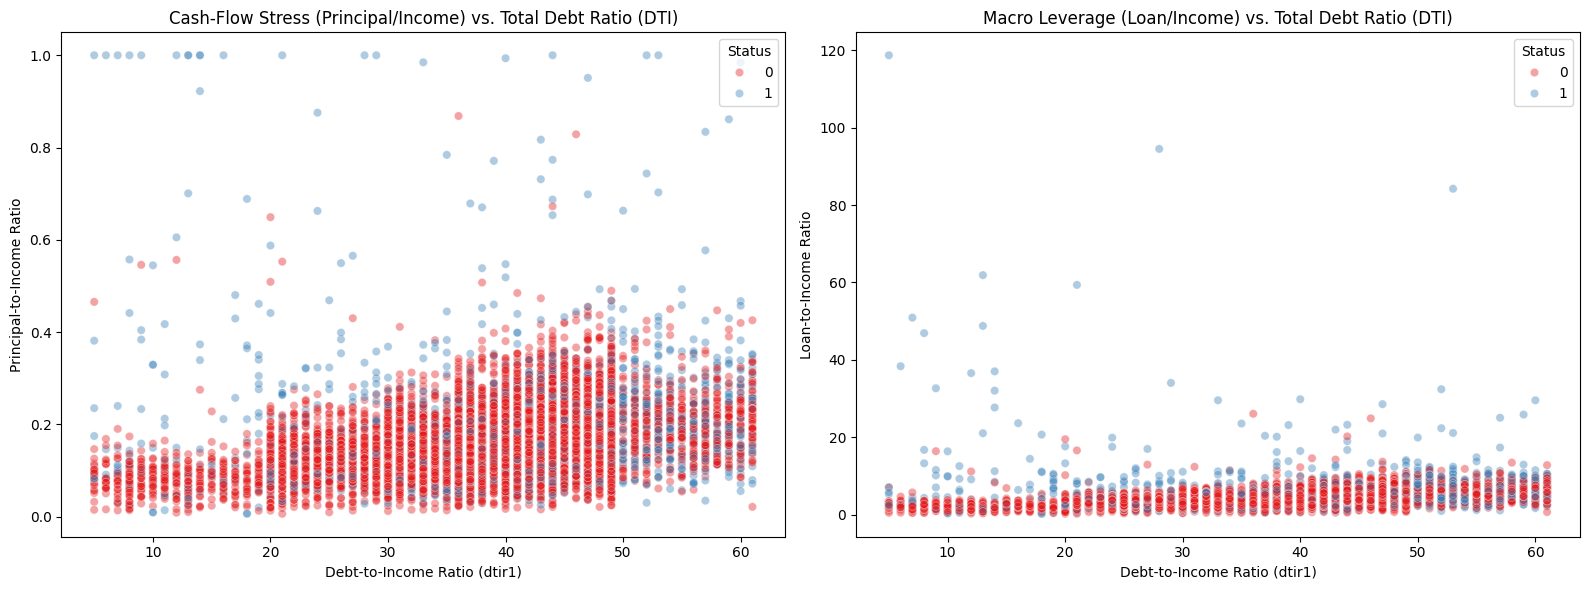

In [76]:
ig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    data=df.sample(frac=0.1, random_state=42),
    x='dtir1',
    y='principal_to_income_ratio',
    hue='Status',
    alpha=0.4,
    ax=axes[0],
    palette='Set1'
)
axes[0].set_title('Cash-Flow Stress (Principal/Income) vs. Total Debt Ratio (DTI)')
axes[0].set_xlabel('Debt-to-Income Ratio (dtir1)')
axes[0].set_ylabel('Principal-to-Income Ratio')


sns.scatterplot(
    data=df.sample(frac=0.1, random_state=42),
    x='dtir1',
    y='loan_income_ratio',
    hue='Status',
    alpha=0.4,
    ax=axes[1],
    palette='Set1'
)
axes[1].set_title('Macro Leverage (Loan/Income) vs. Total Debt Ratio (DTI)')
axes[1].set_xlabel('Debt-to-Income Ratio (dtir1)')
axes[1].set_ylabel('Loan-to-Income Ratio')

plt.tight_layout()
plt.show()

In [77]:
categorical_analysis_list = ['Neg_ammortization', 'loan_limit', 'approv_in_adv']



for col in categorical_analysis_list:
    if col in df.columns:
        print(f"\n--- Distribution & Default Rates for: {col} ---")

        # Calculate the size of each group and the default rate inside it
        group_stats = df.groupby(col, dropna=False)['Status'].agg(['count', 'mean']).reset_index()
        group_stats.columns = [col, 'Total_Borrowers', 'Default_Rate']

        # Convert default rate to a clean percentage string
        group_stats['Default_Rate'] = (group_stats['Default_Rate'] * 100).round(2).astype(str) + '%'
        print(group_stats.to_string(index=False))
        print("-" * 50)


--- Distribution & Default Rates for: Neg_ammortization ---
Neg_ammortization  Total_Borrowers Default_Rate
          neg_amm            15129        44.6%
          not_neg           133420       22.38%
              NaN              121       26.45%
--------------------------------------------------

--- Distribution & Default Rates for: loan_limit ---
loan_limit  Total_Borrowers Default_Rate
   Unknown             3344       26.35%
        cf           135348       23.97%
       ncf             9978       33.21%
--------------------------------------------------

--- Distribution & Default Rates for: approv_in_adv ---
approv_in_adv  Total_Borrowers Default_Rate
      Unknown              908       26.54%
        nopre           124621       25.33%
          pre            23141       20.89%
--------------------------------------------------


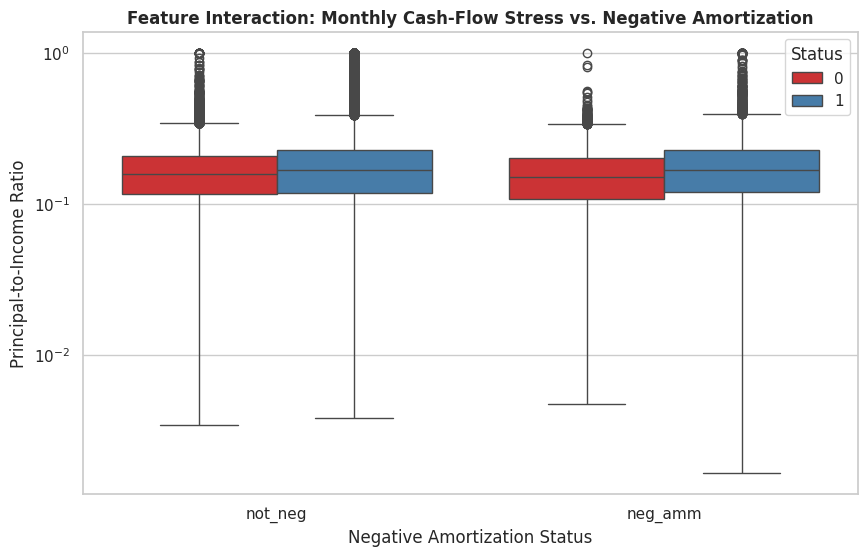

In [78]:


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


sns.boxplot(
    data=df,
    x='Neg_ammortization',
    y='principal_to_income_ratio',
    hue='Status',
    palette='Set1'
)

plt.title('Feature Interaction: Monthly Cash-Flow Stress vs. Negative Amortization', fontsize=12, fontweight='bold')
plt.xlabel('Negative Amortization Status')
plt.ylabel('Principal-to-Income Ratio')
plt.yscale('log') # Log scale helps handle any extreme outliers in the ratio
plt.show()


DATA CLEANING

In [79]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [80]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

target = 'Status'
num_cols = [
    'loan_amount', 'income', 'annual_income', 'term', 'LTV', 'dtir1',
    'principal_to_income_ratio', 'loan_income_ratio', 'Credit_Score'
]
cat_cols = ['Neg_ammortization', 'loan_limit', 'approv_in_adv', 'age', 'loan_purpose']

# 1. Defragment the main dataframe into a clean, unified memory block
df = df.copy()

# 2. Add your high-signal binary missingness flags safely
df['LTV_is_missing'] = df['LTV'].isnull().astype(np.float32)
df['dti_missing'] = df['dtir1'].isnull().astype(np.float32)

# 3. Update your tracking list
num_cols.extend(['LTV_is_missing', 'dti_missing'])

# 4. Isolate features and targets
X = df[num_cols + cat_cols].copy() # Explicitly copy the sliced view
y = df[target].values.astype(np.float32)

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Force clean, independent memory re-allocation for the splits
X_train = pd.DataFrame(X_train.values, columns=X_train.columns).infer_objects()
X_test = pd.DataFrame(X_test.values, columns=X_test.columns).infer_objects()

In [81]:

for col in num_cols:

    train_median = X_train[col].median()


    X_train[col] = X_train[col].fillna(train_median)
    X_test[col]  = X_test[col].fillna(train_median)


for col in cat_cols:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col]  = X_test[col].fillna('Unknown')

print("Missing values remaining in Train:", X_train.isnull().sum().sum())
print("Missing values remaining in Test: ", X_test.isnull().sum().sum())

Missing values remaining in Train: 0
Missing values remaining in Test:  0


We have succesfully filled nans in num_cols using median and cat_cols have been imputed successfully using Unknown

In [82]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# 2. Align the columns of both dataframes to ensure they have the exact same features
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Convert boolean True/False outputs from get_dummies into clean 1.0/0.0 floats for TensorFlow
X_train_encoded = X_train_encoded.astype(np.float32)
X_test_encoded  = X_test_encoded.astype(np.float32)

print(f"Encoded Train Shape: {X_train_encoded.shape}")
print(f"Encoded Test Shape:  {X_test_encoded.shape}")

Encoded Train Shape: (118936, 28)
Encoded Test Shape:  (29734, 28)


In [83]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_final = X_train_encoded.copy()
X_test_final  = X_test_encoded.copy()

X_train_final[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_final[num_cols]  = scaler.transform(X_test_encoded[num_cols])

X_train_matrix = X_train_final.values
X_test_matrix  = X_test_final.values

print("--- Preprocessing Pipeline Complete! ---")
print(f"Final Matrix Shape for TensorFlow Training: {X_train_matrix.shape}")

--- Preprocessing Pipeline Complete! ---
Final Matrix Shape for TensorFlow Training: (118936, 28)


The main reason we use StandardScaler on continuous numbers (like loan_amount) is to shrink them down so they don't completely overwhelm the network's weights.

loan_amount ranges from 0 to 1,000,000+.
principal_to_income_ratio ranges from 0 to 1.

If you don't scale loan_amount, its massive gradients will violently rock the loss landscape, making it impossible for the model to learn.
But your one-hot encoded categorical columns (like Neg_ammortization_Yes) are already bounded tightly between 0 and 1. They are natively in the exact low-magnitude sweet spot that neural networks love. They don't need to be shrunk down because they aren't large enough to blow out the gradients.

Now we need to make a choice here, NNs or XGbs, regressors, random forests? lets try all choices once starting with NNs

NEURAL NETWORKS

In [84]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


model = Sequential([


    Dense(64, activation='relu', input_shape=(X_train_matrix.shape[1],)),
    Dropout(0.2),


    Dense(32, activation='relu'),
    Dropout(0.2),


    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
print("Starting Neural Network Training...")


history = model.fit(
    X_train_matrix, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    verbose=1
)

Starting Neural Network Training...
Epoch 1/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.7876 - loss: 0.3961 - val_auc: 0.8352 - val_loss: 0.3579
Epoch 2/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.8307 - loss: 0.3559 - val_auc: 0.8453 - val_loss: 0.3485
Epoch 3/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.8390 - loss: 0.3486 - val_auc: 0.8493 - val_loss: 0.3433
Epoch 4/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.8447 - loss: 0.3440 - val_auc: 0.8524 - val_loss: 0.3401
Epoch 5/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.8479 - loss: 0.3419 - val_auc: 0.8540 - val_loss: 0.3388
Epoch 6/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.8507 - loss: 0.3392 - val_auc: 0.8563 - val_loss: 0.3358
Epoch 7/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.8526 - loss: 0.3369 - val_auc: 0.8571 - val_loss: 0.3343
Epoch 8/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.8542 - loss: 0.3349 - val_auc: 0.8592 - val_loss: 0.3322
Epoch 9/20
372/372 ━

AUC-ROC stands for Area Under the Receiver Operating Characteristic curve.
Instead of just looking at basic accuracy (which is useless on imbalanced datasets), AUC measures your model's ability to rank risk.

We are getting an auc sscore of 86.35 on trainin set and 86.51 on validation set which converge perfectly showing no data leakage,the NN model fared up well to out features.

MODEL COMPETITION FOR BEST AUC

In [86]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

print("=== 🏁 Running the Tabular Tournament 🏁 ===\n")


print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_matrix, y_train)


print("Training XGBoost Classifier...")
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3.0,
    gamma=1,
    reg_alpha=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_matrix, y_train)

print("\nEvaluating all models on the completely unseen Test Set...")


nn_preds  = model.predict(X_test_matrix).flatten()
lr_preds  = lr_model.predict_proba(X_test_matrix)[:, 1]
xgb_preds = xgb_model.predict_proba(X_test_matrix)[:, 1]


nn_auc  = roc_auc_score(y_test, nn_preds)
lr_auc  = roc_auc_score(y_test, lr_preds)
xgb_auc = roc_auc_score(y_test, xgb_preds)

print("-" * 43)
print(f"1. XGBoost Classifier:      {xgb_auc:.4f}")
print(f"2. TensorFlow Neural Net:   {nn_auc:.4f}")
print(f"3. Logistic Regression:     {lr_auc:.4f}")
print("-" * 43)

=== 🏁 Running the Tabular Tournament 🏁 ===

Training Logistic Regression...
Training XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:01:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Evaluating all models on the completely unseen Test Set...
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
-------------------------------------------
1. XGBoost Classifier:      0.8743
2. TensorFlow Neural Net:   0.8693
3. Logistic Regression:     0.8086
-------------------------------------------


-------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.90      0.92      0.91     22406
         1.0       0.74      0.69      0.72      7328

    accuracy                           0.86     29734
   macro avg       0.82      0.81      0.81     29734
weighted avg       0.86      0.86      0.86     29734

-------------------------------------------------------


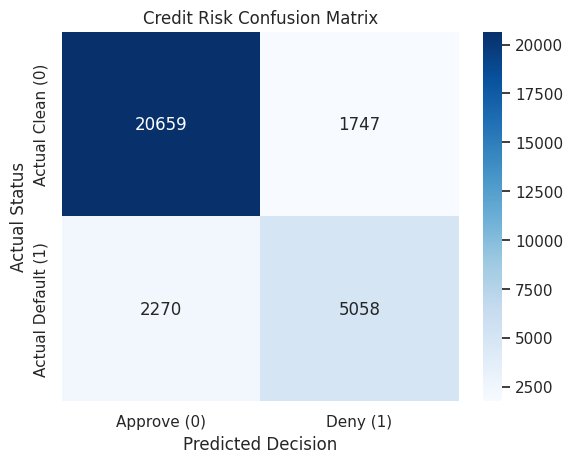

In [90]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

xgb_binary_preds = (xgb_preds >= 0.5).astype(int)



print("-" * 55)
print(classification_report(y_test, xgb_binary_preds))
print("-" * 55)

# 3. Plot a Confusion Matrix heatmap
cm = confusion_matrix(y_test, xgb_binary_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approve (0)', 'Deny (1)'],
            yticklabels=['Actual Clean (0)', 'Actual Default (1)'])
plt.ylabel('Actual Status')
plt.xlabel('Predicted Decision')
plt.title('Credit Risk Confusion Matrix')
plt.show()

Recall is 0.69 (69%): Out of all the people in the test set who actually defaulted, OUR model caught 69% of them before they could do damage.

Precision is 0.74 (74%): When our model flags someone and says "Deny this loan," it is correct 74% of the time. Only 26% of the flagged people were actually clean. This is great because it means the bank isn't blindly rejecting thousands of profitable, good customers just out of paranoia.

Our overall accuracy is 86%. Normally, if a dataset is imbalanced, accuracy is a lying metric (e.g., if only 5% of people default, a dumb model can just guess "No Default" every time and get 95% accuracy while being completely blind to risk).

Our Macro Average F1-score: 0.81. Because your F1-scores for both clean borrowers (0.91) and defaulters (0.72) are high, it proves mathematically that your model is genuinely sharp at predicting both classes, not just riding the coattails of the majority class.

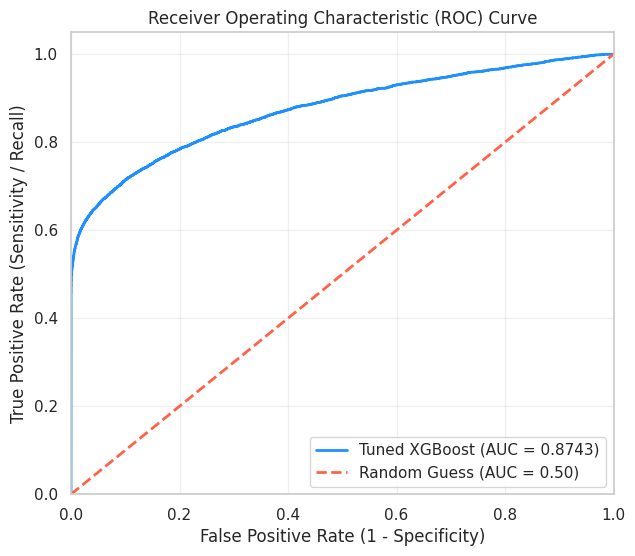

In [94]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(y_test, xgb_preds)


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='dodgerblue', lw=2, label=f'Tuned XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], color='tomato', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [95]:
import joblib
import os

print("📦 Freezing and exporting project artifacts...")

# 1. Save your exact data preprocessing/imputation pipeline
# (This ensures incoming raw data is scaled and handled exactly like your training matrix)
joblib.dump(num_values, 'data_preprocessor_pipeline.pkl')


joblib.dump(tuned_xgb, 'champion_loan_model.pkl')

print("\n✅ SUCCESS! Files generated successfully:")
print(f"   -> data_preprocessor_pipeline.pkl ({os.path.getsize('data_preprocessor_pipeline.pkl') / 1024:.2f} KB)")
print(f"   -> champion_loan_model.pkl ({os.path.getsize('champion_loan_model.pkl') / 1024 / 1024:.2f} MB)")
print("\n👉 ACTION REQUIRED: Open the left side-panel in Colab (folder icon),")
print("   find these two files, right-click, and select 'Download' immediately!")

📦 Freezing and exporting project artifacts...


NameError: name 'num_values' is not defined